In [ ]:
import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


# import metrics MRL
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
############################################################################################
# polynomial interpolation method applied to oil production in Argentina from 2009 to 2025 #
############################################################################################

In [ ]:
prod_Petroleo=pd.read_csv(r"C:\Users\Usuario\Documents\UPA_Extension\Produccion_Petroleo_m3.csv",sep=',')
Prod_Pet=pd.DataFrame(prod_Petroleo)
Prod_Pet

,anio,mes,concepto,cuenca,provincia,empresa,Petróleo(m3)
0,2025,12,Shale Oil,NEUQUINA,Neuquén,YPF S.A.,1616623.09
1,2025,11,Shale Oil,NEUQUINA,Neuquén,YPF S.A.,1497664.71
2,2025,10,Shale Oil,NEUQUINA,Neuquén,YPF S.A.,1494208.17
3,2025,9,Shale Oil,NEUQUINA,Neuquén,YPF S.A.,1386774.63
4,2025,8,Shale Oil,NEUQUINA,Neuquén,YPF S.A.,1382318.37
...,...,...,...,...,...,...,...
72316,2016,7,Producción convencional,NORESTE,Jujuy,PETRO AP S.A.,0.00
72317,2016,10,Shale Oil,NEUQUINA,Rio Negro,KILWER S.A.,0.00
72318,2013,5,Tight_oil,NEUQUINA,Mendoza,SAN JORGE PETROLEUM S.A.,0.00
72319,2017,12,Producción convencional,ÑIRIHUAU,Chubut,KILWER S.A.,0.00


In [ ]:
promedio_Prod_Pet = Prod_Pet.groupby('anio')['Petróleo(m3)'].mean().dropna()
print(promedio_Prod_Pet)

anio
2009     8727.418546
2010     8610.080030
2011     7592.405659
2012     7118.370236
2013     6447.249599
2014     5961.110332
2015     6401.439897
2016     6244.198561
2017     6076.247969
2018     6561.467447
2019     7377.975130
2020     7095.950637
2021     7784.465479
2022     8912.418158
2023     9752.360396
2024    11164.059858
2025    12132.578668
Name: Petróleo(m3), dtype: float64


In [ ]:
ppp=pd.DataFrame({'anio':promedio_Prod_Pet.index,'Petroleo(m3)': promedio_Prod_Pet}).reset_index(drop=True)
ppp

,anio,Petroleo(m3)
0,2009,8727.418546
1,2010,8610.080030
2,2011,7592.405659
3,2012,7118.370236
4,2013,6447.249599
5,2014,5961.110332
6,2015,6401.439897
7,2016,6244.198561
8,2017,6076.247969
9,2018,6561.467447


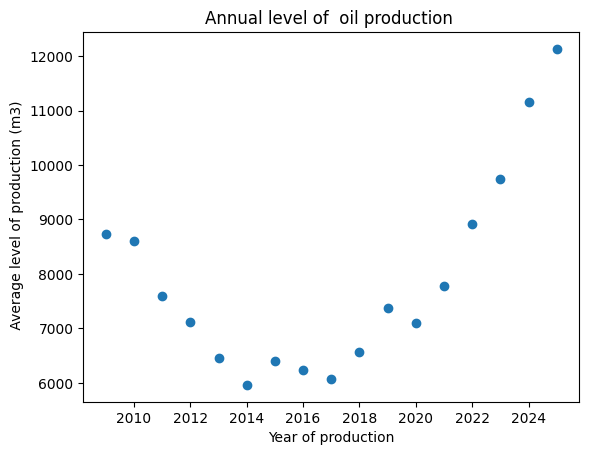

In [ ]:
x_pet=np.array(ppp['anio'] ,dtype=float)    
y_pet=np.array(ppp['Petroleo(m3)'] ,dtype=float)


plt.scatter(x_pet,y_pet)
plt.ylabel(' Average level of production (m3)')
plt.xlabel('Year of production')
plt.title('Annual level of  oil production ')
plt.show()

In [ ]:
ppp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   anio          17 non-null     int64  
 1   Petroleo(m3)  17 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 400.0 bytes


In [ ]:
# polynomial of degree 2
#----------------------
from sklearn.model_selection import train_test_split
x_train_rp,x_test_rp,y_train_rp,y_test_rp=train_test_split(x_pet,y_pet,test_size=0.3, random_state=123)
y_test_rp

array([ 6447.24959944,  6561.46744747, 12132.57866847,  6076.24796878,
        5961.11033152,  6244.19856148])

In [ ]:

print("x_train shape:",x_train_rp.shape)
print("y_train shape:",y_train_rp.shape)
print("x_test shape:",x_test_rp.shape)
print("y_test shape:",y_test_rp.shape)

x_train_rp

x_train shape: (11,)
y_train shape: (11,)
x_test shape: (6,)
y_test shape: (6,)


array([2009., 2019., 2020., 2012., 2010., 2015., 2024., 2021., 2011.,
       2023., 2022.])

In [ ]:

# Transform the training data into a polynomial of degree: 2

transformer2=PolynomialFeatures(degree=2, include_bias=False)
x_poly=transformer2.fit_transform(x_train_rp.reshape(-1, 1))
x_poly

array([[2.009000e+03, 4.036081e+06],
       [2.019000e+03, 4.076361e+06],
       [2.020000e+03, 4.080400e+06],
       [2.012000e+03, 4.048144e+06],
       [2.010000e+03, 4.040100e+06],
       [2.015000e+03, 4.060225e+06],
       [2.024000e+03, 4.096576e+06],
       [2.021000e+03, 4.084441e+06],
       [2.011000e+03, 4.044121e+06],
       [2.023000e+03, 4.092529e+06],
       [2.022000e+03, 4.088484e+06]])

In [ ]:
# Crear un modelo de regresión lineal
model_rp=LinearRegression()

# Entrenar el modelo con datos transformados
model_rp.fit(x_poly,y_train_rp)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:

x_new_poly=transformer2.fit_transform(x_test_rp.reshape(-1, 1))
x_new_poly

# generan las columnas: [x,x^2], si x=2, x^2=4,

array([[2.013000e+03, 4.052169e+06],
       [2.018000e+03, 4.072324e+06],
       [2.025000e+03, 4.100625e+06],
       [2.017000e+03, 4.068289e+06],
       [2.014000e+03, 4.056196e+06],
       [2.016000e+03, 4.064256e+06]])

In [ ]:
pred_rp2=model_rp.predict(x_new_poly) 
pred_rp2

array([ 6677.40524662,  6617.16045141, 12009.4906652 ,  6368.41546154,
        6404.56233868,  6250.06744611])

In [ ]:

x_fit = np.linspace(ppp["anio"].min(), ppp["anio"].max(), 200).reshape(-1,1) 
x_fit_poly =transformer2.transform(x_fit) 
y_fit = model_rp.predict(x_fit_poly)

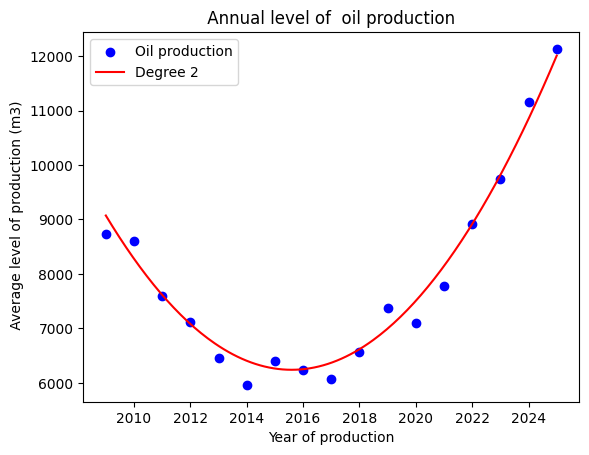

In [ ]:

plt.scatter(x_pet,y_pet,color="blue", label="Oil production")
plt.plot(x_fit,y_fit, label="Degree 2", color='red')
plt.ylabel(' Average level of production (m3)')
plt.xlabel('Year of production')
plt.title(' Annual level of  oil production ')
plt.legend()
plt.show()

In [ ]:

coef=model_rp.coef_
coef
# [a1,a2]

array([-2.62827151e+05,  6.51984872e+01])

In [ ]:

a1=coef[0]
a2=coef[1]

a1=np.round(a1,4)
a2=np.round(a2,4)
a1

np.float64(-262827.151)

In [ ]:

a0=model_rp.intercept_
a0=np.round(a0,4)
a0

np.float64(264882443.5236)

In [ ]:
# polynomial equation

print(" y=",a2,"*x^2+",a1,"x",a0)


 y= 65.1985 *x^2+ -262827.151 x 264882443.5236


In [ ]:
# Metrics

yt2=y_test_rp
pd2=pred_rp2

MAE=mean_absolute_error(yt2,pd2)  
MSE=mean_squared_error(yt2,pd2)
RMSE=MSE**(1/2.0)

print("The mean absolte error (MAE) on test set: {:.5f}".format(MAE))  
print("The mean squared error (MSE) on test set: {:.4f}".format(MSE)) 
print("The root mean squared error (RMSE) on test set: {:.4f}".format(RMSE)) 
print('Variance score R2: %.2f' % r2_score(yt2,pd2))

The mean absolte error (MAE) on test set: 191.73751
The mean squared error (MSE) on test set: 58878.3266
The root mean squared error (RMSE) on test set: 242.6486
Variance score R2: 0.99


In [ ]:
# polynomial of degree 3
#----------------------
transformer3=PolynomialFeatures(degree=3, include_bias=False)
x_poly3=transformer3.fit_transform(x_train_rp.reshape(-1, 1))
x_poly3

array([[2.00900000e+03, 4.03608100e+06, 8.10848673e+09],
       [2.01900000e+03, 4.07636100e+06, 8.23017286e+09],
       [2.02000000e+03, 4.08040000e+06, 8.24240800e+09],
       [2.01200000e+03, 4.04814400e+06, 8.14486573e+09],
       [2.01000000e+03, 4.04010000e+06, 8.12060100e+09],
       [2.01500000e+03, 4.06022500e+06, 8.18135338e+09],
       [2.02400000e+03, 4.09657600e+06, 8.29146982e+09],
       [2.02100000e+03, 4.08444100e+06, 8.25465526e+09],
       [2.01100000e+03, 4.04412100e+06, 8.13272733e+09],
       [2.02300000e+03, 4.09252900e+06, 8.27918617e+09],
       [2.02200000e+03, 4.08848400e+06, 8.26691465e+09]])

In [ ]:

model_rp3=LinearRegression()
model_rp3.fit(x_poly3,y_train_rp)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
x_new_poly3=transformer3.fit_transform(x_test_rp.reshape(-1, 1))
x_new_poly3

array([[2.01300000e+03, 4.05216900e+06, 8.15701620e+09],
       [2.01800000e+03, 4.07232400e+06, 8.21794983e+09],
       [2.02500000e+03, 4.10062500e+06, 8.30376562e+09],
       [2.01700000e+03, 4.06828900e+06, 8.20573891e+09],
       [2.01400000e+03, 4.05619600e+06, 8.16917874e+09],
       [2.01600000e+03, 4.06425600e+06, 8.19354010e+09]])

In [ ]:
pred_rp3=model_rp3.predict(x_new_poly3) 
pred_rp3

array([ 6893.79779243,  6562.8522644 , 12477.20408249,  6383.36707115,
        6603.69358063,  6337.59861946])

In [ ]:
x_fit3 = np.linspace(ppp["anio"].min(), ppp["anio"].max(), 200).reshape(-1,1)
x_fit_poly3 =transformer3.transform(x_fit3)
y_fit3 = model_rp3.predict(x_fit_poly3)


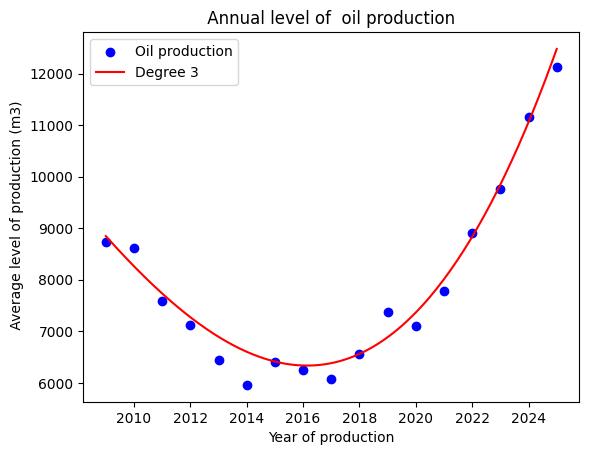

In [ ]:
plt.scatter(x_pet,y_pet,color="blue", label="Oil production")
plt.plot(x_fit3,y_fit3, label="Degree 3", color='red')
plt.ylabel(' Average level of production (m3)')
plt.xlabel('Year of production')
plt.title(' Annual level of  oil production ')
plt.legend()
plt.show()

In [ ]:
coef3=model_rp3.coef_
coef3
# [a1,a2]

array([ 2.18610822e+07, -1.09052180e+04,  1.81326663e+00])

In [ ]:
a1=coef3[0]
a2=coef3[1]
a3=coef3[2]

a1=np.round(a1,4)
a2=np.round(a2,4)
a3=np.round(a3,4)

a1,a2,a3

(np.float64(21861082.1569), np.float64(-10905.218), np.float64(1.8133))

In [ ]:
a0=model_rp3.intercept_
a0=np.round(a0,4)
a0

np.float64(-14607410462.4523)

In [ ]:
# polynomial equation
print(" y=",a3,"*x^3+",a2,"*x^2+",a1,"x",a0)


 y= 1.8133 *x^3+ -10905.218 *x^2+ 21861082.1569 x -14607410462.4523


In [ ]:
# Metrics

yt3=y_test_rp
pd3=pred_rp3

MAE=mean_absolute_error(yt3,pd3)  
MSE=mean_squared_error(yt3,pd3)
RMSE=MSE**(1/2.0)
print("The mean absolte error (MAE) on test set: {:.5f}".format(MAE))  

print("The mean squared error (MSE) on test set: {:.4f}".format(MSE)) 
print("The root mean squared error (RMSE) on test set: {:.4f}".format(RMSE)) 
print('Variance score R2: %.2f' % r2_score(yt3,pd3))

The mean absolte error (MAE) on test set: 305.94347
The mean squared error (MSE) on test set: 139022.1380
The root mean squared error (RMSE) on test set: 372.8567
Variance score R2: 0.97


In [ ]:
# polynomial of degree 4
#----------------------
transformer4=PolynomialFeatures(degree=4, include_bias=False)
x_poly4=transformer4.fit_transform(x_train_rp.reshape(-1, 1))
x_poly4

array([[2.00900000e+03, 4.03608100e+06, 8.10848673e+09, 1.62899498e+13],
       [2.01900000e+03, 4.07636100e+06, 8.23017286e+09, 1.66167190e+13],
       [2.02000000e+03, 4.08040000e+06, 8.24240800e+09, 1.66496642e+13],
       [2.01200000e+03, 4.04814400e+06, 8.14486573e+09, 1.63874698e+13],
       [2.01000000e+03, 4.04010000e+06, 8.12060100e+09, 1.63224080e+13],
       [2.01500000e+03, 4.06022500e+06, 8.18135338e+09, 1.64854271e+13],
       [2.02400000e+03, 4.09657600e+06, 8.29146982e+09, 1.67819349e+13],
       [2.02100000e+03, 4.08444100e+06, 8.25465526e+09, 1.66826583e+13],
       [2.01100000e+03, 4.04412100e+06, 8.13272733e+09, 1.63549147e+13],
       [2.02300000e+03, 4.09252900e+06, 8.27918617e+09, 1.67487936e+13],
       [2.02200000e+03, 4.08848400e+06, 8.26691465e+09, 1.67157014e+13]])

In [ ]:
model_rp4=LinearRegression()
model_rp4.fit(x_poly4,y_train_rp)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
x_new_poly4=transformer4.fit_transform(x_test_rp.reshape(-1, 1))
x_new_poly4

array([[2.01300000e+03, 4.05216900e+06, 8.15701620e+09, 1.64200736e+13],
       [2.01800000e+03, 4.07232400e+06, 8.21794983e+09, 1.65838228e+13],
       [2.02500000e+03, 4.10062500e+06, 8.30376562e+09, 1.68151254e+13],
       [2.01700000e+03, 4.06828900e+06, 8.20573891e+09, 1.65509754e+13],
       [2.01400000e+03, 4.05619600e+06, 8.16917874e+09, 1.64527260e+13],
       [2.01600000e+03, 4.06425600e+06, 8.19354010e+09, 1.65181768e+13]])

In [ ]:
pred_rp4=model_rp4.predict(x_new_poly4) 
pred_rp4

array([ 6893.82475281,  6563.15488434, 12478.56782913,  6383.76036453,
        6603.90019989,  6338.00705338])

In [ ]:
x_fit4= np.linspace(ppp["anio"].min(), ppp["anio"].max(), 200).reshape(-1,1)
x_fit_poly4=transformer4.transform(x_fit4)
y_fit4= model_rp4.predict(x_fit_poly4)


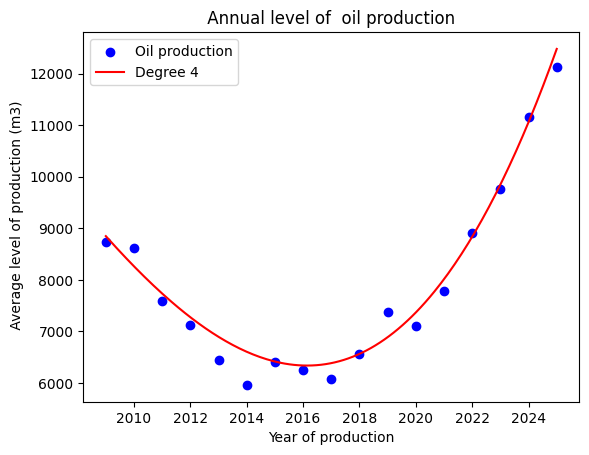

In [ ]:
plt.scatter(x_pet,y_pet,color="blue", label="Oil production")
plt.plot(x_fit4,y_fit4, label="Degree 4", color='red')
plt.ylabel(' Average level of production (m3)')
plt.xlabel('Year of production')
plt.title(' Annual level of  oil production ')
plt.legend()
plt.show()

In [ ]:
# Metrics

yt4=y_test_rp
pd4=pred_rp4

MAE=mean_absolute_error(yt4,pd4)  
MSE=mean_squared_error(yt4,pd4)
RMSE=MSE**(1/2.0)
print("The mean absolte error (MAE) on test set: {:.5f}".format(MAE))  

print("The mean squared error (MSE) on test set: {:.4f}".format(MSE)) 
print("The root mean squared error (RMSE) on test set: {:.4f}".format(RMSE)) 
print('Variance score R2: %.2f' % r2_score(yt4,pd4))

The mean absolte error (MAE) on test set: 306.39375
The mean squared error (MSE) on test set: 139280.5727
The root mean squared error (RMSE) on test set: 373.2031
Variance score R2: 0.97


In [ ]:
# Lagrange interpolation method *
################################
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

x_pet = np.array(ppp['anio'], dtype=float)
y_pet = np.array(ppp['Petroleo(m3)'], dtype=float)

poly_lagrange = lagrange(x_pet, y_pet)

print("Lagrange equation:")
print(poly_lagrange)

x_new = np.linspace(min(x_pet), max(x_pet), 300)
y_new = poly_lagrange(x_new)


Lagrange equation:
           16            15         14             13             12
1.781e-07 x  - 0.005749 x  + 86.96 x  - 8.185e+05 x  + 5.365e+09 x 
              11             10             9             8
 - 2.597e+13 x  + 9.604e+16 x  - 2.767e+20 x + 6.279e+23 x
              7             6             5             4             3
 - 1.126e+27 x + 1.589e+30 x - 1.749e+33 x + 1.469e+36 x - 9.119e+38 x
              2
 + 3.941e+41 x - 1.06e+44 x + 1.336e+46
